# ***Student Name: Tushar Panchal***

# ***En. No. : 21162101014***

# ***Branch: CBA***

# ***Batch:  71***

# ***Subject: ML (Machine Learning)***

# **EXPERIMENT 10**
<hr>

# Stock price prediction using RNN

<hr>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
import yfinance as yf

In [ ]:
def print_separator(title=""):
    print("\n" + "-" * 100)
    print(f"{title:^100}")
    print("-" * 100 + "\n")

print_separator("STEP 1: Fetching Stock Data")

ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2020-01-01"

df = yf.download(ticker, start=start_date, end=end_date)

print(f"\n\nFetched {len(df)} rows of data for {ticker} from {start_date} to {end_date}.")
print(f"\nSample data : \n\n{df.head()}")

# Using only the 'Open' prices for training
training_set = df['Open'].values.reshape(-1, 1)

[*********************100%***********************]  1 of 1 completed


----------------------------------------------------------------------------------------------------
                                    STEP 1: Fetching Stock Data                                     
----------------------------------------------------------------------------------------------------



Fetched 1258 rows of data for AAPL from 2015-01-01 to 2020-01-01.

Sample data : 

Price                      Adj Close      Close       High        Low  \
Ticker                          AAPL       AAPL       AAPL       AAPL   
Date                                                                    
2015-01-02 00:00:00+00:00  24.347168  27.332500  27.860001  26.837500   
2015-01-05 00:00:00+00:00  23.661274  26.562500  27.162500  26.352501   
2015-01-06 00:00:00+00:00  23.663500  26.565001  26.857500  26.157499   
2015-01-07 00:00:00+00:00  23.995310  26.937500  27.049999  26.674999   
2015-01-08 00:00:00+00:00  24.917267  27.972500  28.037500  27.174999   

Price                    

In [ ]:
print_separator("STEP 2: Feature Scaling")

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

print("Data has been scaled to the range [0, 1].")
print(f"\nSample scaled values : \n\n{training_set_scaled[:5]}")


----------------------------------------------------------------------------------------------------
                                      STEP 2: Feature Scaling                                       
----------------------------------------------------------------------------------------------------

Data has been scaled to the range [0, 1].

Sample scaled values : 

[[0.10635441]
 [0.09094074]
 [0.08223947]
 [0.08552107]
 [0.09561458]]


In [ ]:
print_separator("STEP 3: Creating the Data Structure")

# Create training data with 60 timesteps
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

print(f"Training data created with {X_train.shape[0]} samples and {X_train.shape[1]} timesteps.")
print(f"\nFirst sample (X_train[0]) :\n\n{X_train[0]}")
print(f"\nFirst target (y_train[0]) : {y_train[0]}")

# Reshaping for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


----------------------------------------------------------------------------------------------------
                                STEP 3: Creating the Data Structure                                 
----------------------------------------------------------------------------------------------------

Training data created with 1198 samples and 60 timesteps.

First sample (X_train[0]) :

[0.10635441 0.09094074 0.08223947 0.08552107 0.09561458 0.11271877
 0.11237072 0.10655331 0.09466986 0.09944312 0.08467581 0.08870325
 0.09422234 0.10073589 0.1108791  0.11803897 0.11147573 0.13738066
 0.13086715 0.14120924 0.13946899 0.14170645 0.14170645 0.14926411
 0.14926411 0.14195507 0.15000994 0.16293754 0.17929593 0.18536197
 0.18640612 0.18710222 0.19132854 0.19202464 0.19898571 0.21350439
 0.20664279 0.1928699  0.19888624 0.19515712 0.19371523 0.19441133
 0.19182579 0.19093076 0.18874304 0.18103622 0.17278242 0.16065035
 0.17104218 0.16845663 0.17850041 0.18396977 0.19267105 0.19018497
 0.1

In [ ]:
print_separator("STEP 4: Building the RNN")

# Initialize the RNN
regressor = Sequential()

# Add LSTM layers with Dropout
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Add the output layer
regressor.add(Dense(units=1))

# Compile the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')

print("RNN Model Summary : \n")
print(regressor.summary())


----------------------------------------------------------------------------------------------------
                                      STEP 4: Building the RNN                                      
----------------------------------------------------------------------------------------------------

RNN Model Summary : 



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                       │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_18 (LSTM)                       │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_19 (LSTM)                       │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
print_separator("STEP 5: Training the RNN")

epochs = 20
batch_size = 32
history = regressor.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

print(f"\nModel trained for {epochs} epochs with batch size {batch_size}.")



----------------------------------------------------------------------------------------------------
                                      STEP 5: Training the RNN                                      
----------------------------------------------------------------------------------------------------

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - loss: 0.0025
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0024
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0021
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.0021
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 0.0020
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - loss: 0.0025
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0021
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0021
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0022
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - loss: 0.0022
Epoch 11/20
38/38 ━━━━━

In [ ]:
print_separator("STEP 6: Preparing the Test Data")

test_start_date = "2020-01-01"
test_end_date = "2023-01-01"

df_test = yf.download(ticker, start=test_start_date, end=test_end_date)
real_stock_price = df_test['Open'].values.reshape(-1, 1)

print(f"Fetched test data with {len(df_test)} rows from {test_start_date} to {test_end_date}.")
print(f"\nSample test data :\n\n{df_test.head()}")

# Combine train and test sets for continuity
dataset_total = pd.concat((df['Open'], df_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(df_test) - 60:].values.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Prepared test data with {X_test.shape[0]} samples.")


----------------------------------------------------------------------------------------------------
                                  STEP 6: Preparing the Test Data                                   
----------------------------------------------------------------------------------------------------



[*********************100%***********************]  1 of 1 completed

Fetched test data with 756 rows from 2020-01-01 to 2023-01-01.

Sample test data :

Price                      Adj Close      Close       High        Low  \
Ticker                          AAPL       AAPL       AAPL       AAPL   
Date                                                                    
2020-01-02 00:00:00+00:00  72.796021  75.087502  75.150002  73.797501   
2020-01-03 00:00:00+00:00  72.088295  74.357498  75.144997  74.125000   
2020-01-06 00:00:00+00:00  72.662712  74.949997  74.989998  73.187500   
2020-01-07 00:00:00+00:00  72.320976  74.597504  75.224998  74.370003   
2020-01-08 00:00:00+00:00  73.484352  75.797501  76.110001  74.290001   

Price                           Open     Volume  
Ticker                          AAPL       AAPL  
Date                                             
2020-01-02 00:00:00+00:00  74.059998  135480400  
2020-01-03 00:00:00+00:00  74.287498  146322800  
2020-01-06 00:00:00+00:00  73.447502  118387200  
2020-01-07 00:00:00+00:00  74.9

In [ ]:
print_separator("STEP 7: Predicting Stock Prices")

# Predict stock prices
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

print(f"\nPredicted stock prices for {len(predicted_stock_price)} test samples.")


----------------------------------------------------------------------------------------------------
                                  STEP 7: Predicting Stock Prices                                   
----------------------------------------------------------------------------------------------------

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

Predicted stock prices for 756 test samples.



----------------------------------------------------------------------------------------------------
                                  STEP 8: Visualizing the Results                                   
----------------------------------------------------------------------------------------------------



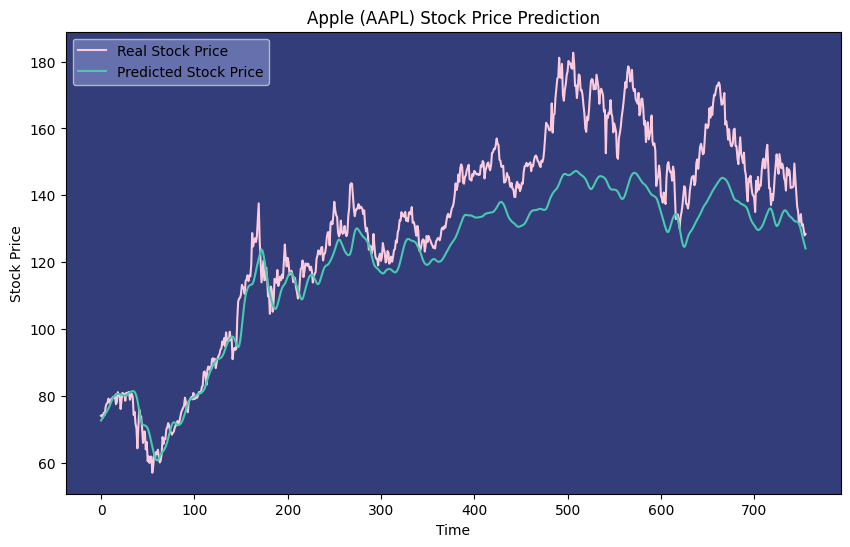

In [ ]:
print_separator("STEP 8: Visualizing the Results")

plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('#333d79')
plt.plot(real_stock_price, color='#facadf', label='Real Stock Price')
plt.plot(predicted_stock_price, color='#48c9b0', label='Predicted Stock Price')
plt.title(f'Apple ({ticker}) Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend(facecolor='#737db9')
plt.show()

**As seen here, the prediction got more accurate for time nearest to that of trained dataset, while less accurate for farther future time**